In [1]:
print(1)

1


In [2]:
import pickle
import scipy
import abtem
import numpy as np

from abtem.waves import Probe
from abtem.core.energy import energy2wavelength
from matplotlib import pyplot as plt
from abtem.core.energy import energy2sigma
from abtem.potentials.iam import PotentialArray
from abtem import PixelatedDetector
from abtem.scan import GridScan
from quantem.core.visualization import show_2d


VOLT_INTEGRAL_TO_PHASE_FACT = (
    scipy.constants.e /
    (scipy.constants.hbar * 0.45 * scipy.constants.c)  # if acc is 60e3
) # [1/(Vm)]

ACC_VOLTAGE     = 60e3  # eV
PROBE_SEMIANGLE = 30    # mrad
PROBE_DEFOCUS   = 0     # Å
SCAN_STEP_SIZE  = 0.15  # Å

def get_measurement(
    phase_image,
    dx,
    dy,
    acc_voltage=ACC_VOLTAGE,
    probe_semiangle=PROBE_SEMIANGLE,
    probe_defocus=PROBE_DEFOCUS,
    scan_step_size=SCAN_STEP_SIZE,
    pad_frac=None,
    plot=False,
):
    sigma = float(energy2sigma(acc_voltage))
    V = phase_image / (sigma)
    V_slices = V[np.newaxis, :, :].astype(np.float32)

    potential = PotentialArray(
        array=V_slices,
        slice_thickness=1,
        sampling=(dx, dy),
    )

    # create probe and scan
    probe = Probe(
        energy=acc_voltage,
        semiangle_cutoff=probe_semiangle, 
        defocus=probe_defocus
    )

    # probe.grid.match(potential)
    probe.match_grid(potential)
    probe.show(cbar=True)

    if pad_frac is None:
        scan = GridScan(
            start=(0.0, 0.0),
            end=potential.extent,
            potential=potential,
            sampling=scan_step_size,
            endpoint=True,
        )
    else:
        scan = GridScan(
            start=(pad_frac, pad_frac),
            end=(1-pad_frac, 1-pad_frac),
            fractional=True,
            potential=potential,
            sampling=scan_step_size,
            endpoint=True,
        )

    if plot:
        fig, ax = plt.subplots()
        potential.show(ax=ax)
        scan.add_to_plot(ax)
        plt.show()
    
    detector = PixelatedDetector(max_angle='valid')

    measurement = probe.scan(potential, scan=scan, detectors=detector)
    measurement.compute()   # typically dims: (Nx_scan, Ny_scan, Nkx, Nky)

    if plot:
        show_2d(measurement.array.mean((0,1)), cbar=True, cmap='turbo', vmax=0.000001)

    return measurement



In [3]:
with open('bcenters_base_excited_phases_wide_fov.pkl', 'rb') as f:
    data = pickle.load(f)

base_phase = data['base']
excited_phase = data['excited']
x = data['x']
y = data['y']

dx = x[1] - x[0]
dy = y[1] - y[0]

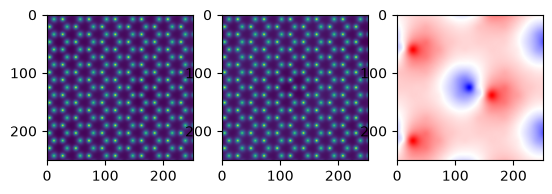

In [4]:
from matplotlib import pyplot as plt
plt.subplot(1,3,1)
plt.imshow(base_phase)

plt.subplot(1,3,2)
plt.imshow(excited_phase)

plt.subplot(1,3,3)
plt.imshow(excited_phase - base_phase, cmap='bwr')

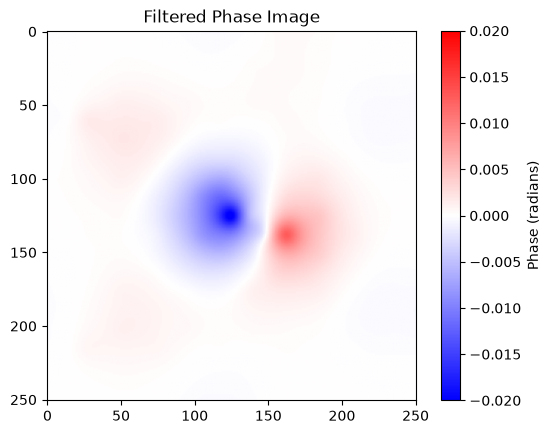

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculate phase difference
diff_phase = excited_phase - base_phase

# 2. Generate a 2D Hamming filter matching the shape of your image
# We take the outer product of a vertical window and a horizontal window
window_y = np.hamming(diff_phase.shape[0])
window_x = np.hamming(diff_phase.shape[1])
humming_filter = np.outer(window_y, window_x)

# 3. Apply the filter to the data
filtered_diff_phase = diff_phase * humming_filter

# 4. Plot after Hamming filter
plt.imshow(filtered_diff_phase, cmap='bwr', vmin=-0.02, vmax=0.02)
plt.colorbar(label='Phase (radians)')
plt.title('Filtered Phase Image')
plt.show()


In [6]:
excited_phase = base_phase + filtered_diff_phase

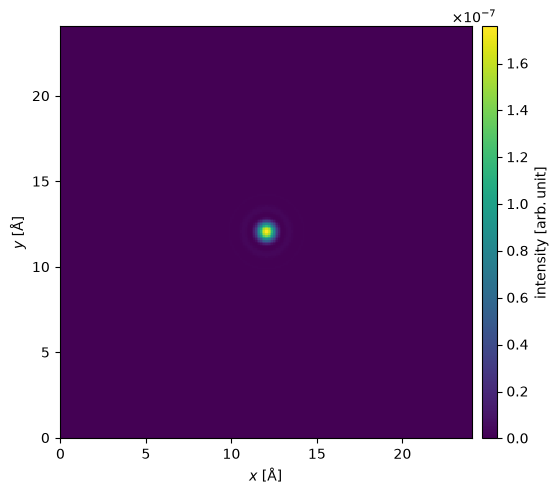

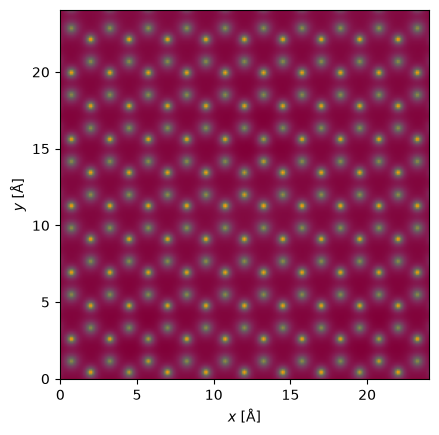

tasks:   2%|1         | 2/123 [00:02<02:53,  1.43s/it]

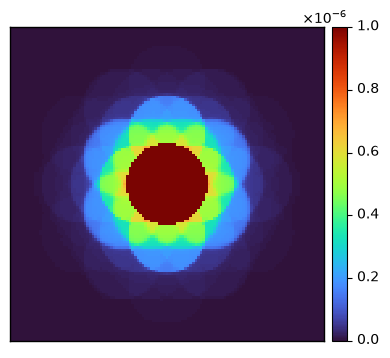

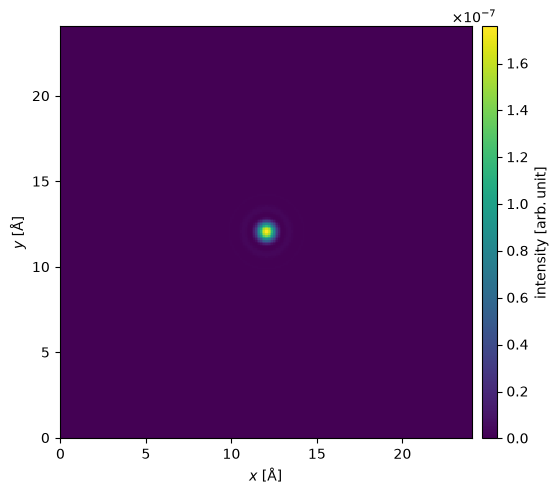

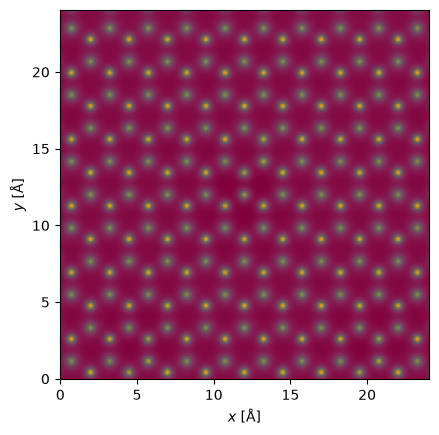

tasks:   2%|1         | 2/123 [00:01<01:59,  1.01it/s]

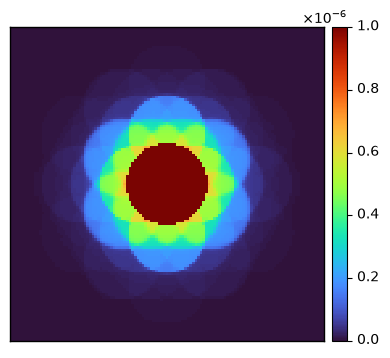

In [7]:
scan_step_size = 0.15

base_meas = get_measurement(
    base_phase,
    dx,
    dy,
    scan_step_size=scan_step_size,
    plot=True
)

excited_meas = get_measurement(
    excited_phase,
    dx,
    dy,
    scan_step_size=scan_step_size,
    plot=True
)

# Reconstruct and subtract
seeing how the naiive version looks like, and maybe understanding how the signal might be distorted in the process.

In [8]:
from quantem.core.datastructures import Dataset4d
from quantem.diffractive_imaging.direct_ptychography import DirectPtychography

# datacube: np.ndarray, shape (scan_y, scan_x, det_y, det_x)
dataset_base = Dataset4d.from_array(
    base_meas.array,
    sampling=(scan_step_size, scan_step_size, base_meas.sampling[0], base_meas.sampling[0]),
    units=("A", "A", "A^-1", "A^-1"),  # or "mrad" for the last two
)

ptycho_base = DirectPtychography.from_dataset4d(
    dataset_base,
    energy=60e3,                      # eV
    semiangle_cutoff=30,   # mrad
    aberration_coefs={"defocus": 0},  # Å
).reconstruct(deconvolution_kernel="ssb")

# ptycho.visualize()
obj_base = ptycho_base.obj  # reconstructed phase, numpy array


# datacube: np.ndarray, shape (scan_y, scan_x, det_y, det_x)
dataset_excited = Dataset4d.from_array(
    excited_meas.array,
    sampling=(scan_step_size, scan_step_size, excited_meas.sampling[0], excited_meas.sampling[0]),
    units=("A", "A", "A^-1", "A^-1"),  # or "mrad" for the last two
)

ptycho_excited = DirectPtychography.from_dataset4d(
    dataset_excited,
    energy=60e3,                      # eV
    semiangle_cutoff=30,   # mrad
    aberration_coefs={"defocus": 0},  # Å
).reconstruct(deconvolution_kernel="ssb")

# ptycho.visualize()
obj_excited = ptycho_excited.obj  # reconstructed phase, numpy array

  0%|          | 0/673 [00:00<?, ?it/s]

  0%|          | 0/673 [00:00<?, ?it/s]

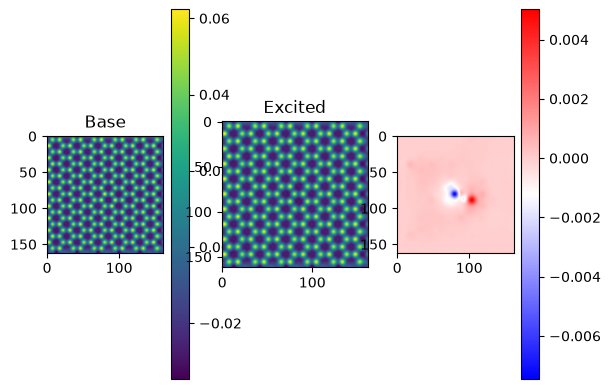

In [9]:
plt.subplot(1,3,1)
plt.imshow(obj_base)
plt.colorbar()
plt.title("Base")
plt.subplot(1,3,2)
plt.imshow(obj_excited)
plt.title("Excited")
plt.subplot(1,3,3)
plt.imshow(obj_excited - obj_base, cmap='bwr') 
plt.colorbar()
# so the difference is just something we get from the regular SSB filtering.

In [10]:
base_meas.shape[0] * scan_step_size  # sanity check, that we get to the axis size (24)

24.3

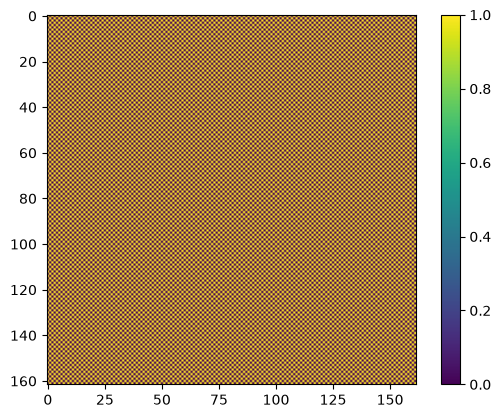

In [11]:
# create the cheker-board mask
scan_mask = np.zeros(base_meas.shape[:2], dtype=np.uint8)
x_i = np.arange(scan_mask.shape[0])
y_i = np.arange(scan_mask.shape[1])
for i in x_i:
    for j in y_i:
        if (i + j) % 2 == 0:
            scan_mask[i, j] = 1
plt.imshow(scan_mask)
plt.colorbar()

# merge the datasets
merged_scan = np.array(base_meas.array)
merged_scan[scan_mask == 1, :, :] = np.array(excited_meas.array)[scan_mask == 1, :, :]

# Formal SSB
Regular SSB over the interlaced image - what should happen? god knows

  0%|          | 0/673 [00:00<?, ?it/s]

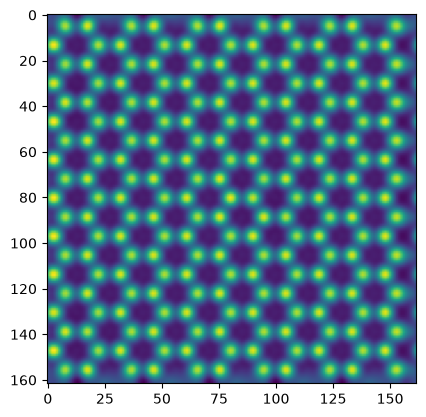

In [12]:
from quantem.core.datastructures import Dataset4d
from quantem.diffractive_imaging.direct_ptychography import DirectPtychography

# datacube: np.ndarray, shape (scan_y, scan_x, det_y, det_x)
dataset = Dataset4d.from_array(
    base_meas.array,
    sampling=(scan_step_size, scan_step_size, base_meas.sampling[0], base_meas.sampling[0]),
    units=("A", "A", "A^-1", "A^-1"),  # or "mrad" for the last two
)

ptycho = DirectPtychography.from_dataset4d(
    dataset,
    energy=60e3,                      # eV
    semiangle_cutoff=30,   # mrad
    aberration_coefs={"defocus": 0},  # Å
).reconstruct(deconvolution_kernel="ssb")

# ptycho.visualize()
obj = ptycho.obj  # reconstructed phase, numpy array


plt.imshow(obj)

  0%|          | 0/673 [00:00<?, ?it/s]

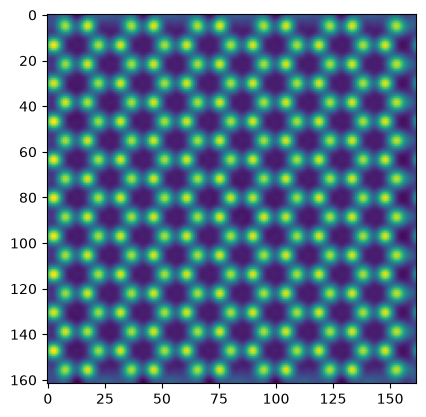

In [13]:
from quantem.core.datastructures import Dataset4d
from quantem.diffractive_imaging.direct_ptychography import DirectPtychography

# datacube: np.ndarray, shape (scan_y, scan_x, det_y, det_x)
dataset_merged = Dataset4d.from_array(
    merged_scan,
    sampling=(scan_step_size, scan_step_size, 0.04150066401062413, 0.04150066401062413),
    units=("A", "A", "A^-1", "A^-1"),  # or "mrad" for the last two
)

ptycho_merged = DirectPtychography.from_dataset4d(
    dataset_merged,
    energy=60e3,                      # eV
    semiangle_cutoff=30,   # mrad
    aberration_coefs={"defocus": 0},  # Å
).reconstruct(deconvolution_kernel="ssb")

# ptycho_merged.visualize()
obj_merged = ptycho_merged.obj  # reconstructed phase, numpy array

plt.imshow(obj_merged)

# Multiplexed SSB - Assuming that I = I_0 + \delta I
In this part, we assume that the DP are linear with the delta I. 

In [14]:
ptycho_merged._preprocess()

In [15]:
ptycho_merged._vbf_fourier.shape

torch.Size([673, 162, 162])

In [16]:
import torch
ptycho_merged._vbf_fourier = torch.fft.fftshift(ptycho_merged._vbf_fourier, dim=(-1, -2))

  0%|          | 0/673 [00:00<?, ?it/s]

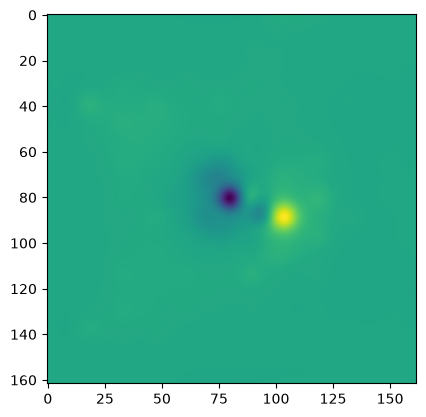

In [17]:
ptycho_merged.reconstruct(deconvolution_kernel="ssb")
obj_merged = ptycho_merged.obj  # reconstructed phase, numpy array
plt.imshow(obj_merged)

(np.float64(-0.5), np.float64(161.5), np.float64(161.5), np.float64(-0.5))

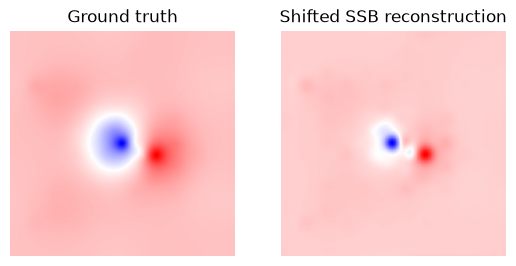

In [18]:
plt.subplot(1,2,1)
plt.title('Ground truth')
plt.imshow(excited_phase - base_phase, cmap='bwr')
plt.axis('off')
plt.subplot(1,2,2)
plt.title('Shifted SSB reconstruction')
plt.imshow(obj_merged, cmap='bwr')
plt.axis('off')

# Scan performences over different doses


In [19]:
def merge_scan(meas_a, meas_b, scan_mask, dose=None, normalize=True):
    """Interlace two noise-free measurements on a checkerboard scan pattern.

    `dose` (electrons / Å^2) applies Poisson shot noise to each measurement
    before interlacing; `None` keeps the simulation noise-free.
    """
    m_a = meas_a if dose is None else meas_a.poisson_noise(dose)
    m_b = meas_b if dose is None else meas_b.poisson_noise(dose)

    dcube_a = np.array(m_a.array)
    dcube_b = np.array(m_b.array)

    merged_scan = np.where(scan_mask[..., np.newaxis, np.newaxis] == 1, dcube_b, dcube_a)

    if normalize:
        merged_scan = merged_scan / merged_scan.sum(axis=(2, 3), keepdims=True)

    return merged_scan

In [20]:
merged_scan = merge_scan(base_meas, excited_meas, scan_mask, dose=None, normalize=False)

In [21]:
base_meas.shape, ptycho_merged._vbf_fourier.shape

((162, 162, 119, 119), torch.Size([673, 162, 162]))

In [105]:
dataset_merged = Dataset4d.from_array(
    merged_scan,
    sampling=(scan_step_size, scan_step_size, 0.04150066401062413, 0.04150066401062413),
    units=("A", "A", "A^-1", "A^-1"),  # or "mrad" for the last two
)

ptycho_merged = DirectPtychography.from_dataset4d(
    dataset_merged,
    energy=60e3,                      # eV
    semiangle_cutoff=30,   # mrad
    aberration_coefs={"defocus": 0},  # Å
).reconstruct(deconvolution_kernel="ssb")

  0%|          | 0/673 [00:00<?, ?it/s]

/tmp/ipykernel_839602/2684126932.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.abs(ptycho_merged._vbf_fourier).sum(axis=0)[60:100,60:100], cmap='hot')


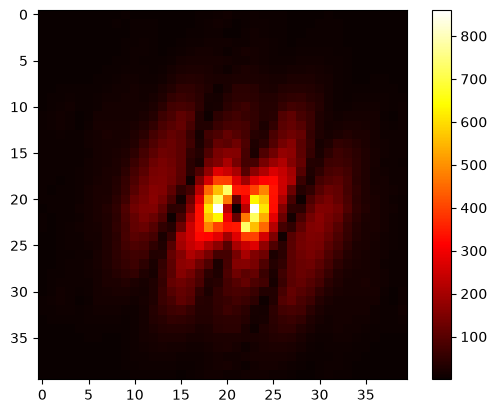

In [115]:
from scipy.ndimage import gaussian_filter
plt.imshow(np.abs(ptycho_merged._vbf_fourier).sum(axis=0)[60:100,60:100], cmap='hot')
plt.colorbar()

In [107]:
ptycho_merged._return_upsampled_qgrid()[0].shape, ptycho_merged._vbf_fourier.shape, dataset.shape

(torch.Size([162, 162]), torch.Size([673, 162, 162]), (162, 162, 119, 119))

In [108]:
ft_ax = np.fft.fftfreq(dataset_merged.shape[0], d=scan_step_size)
ft_ax[ft_ax < 0] = ft_ax[ft_ax < 0] + 1/scan_step_size
ft_ax.max()

np.float64(6.625514403292182)

/tmp/ipykernel_839602/3581377574.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  q_r = np.abs(q_x) + np.abs(q_y)
/tmp/ipykernel_839602/3581377574.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  scan_spectra_base = np.abs(ptycho._vbf_fourier).sum(axis=0)
/tmp/ipykernel_839602/3581377574.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  scan_spectra_merged = np.abs(ptycho_merged._vbf_fourier).sum(axis=0)


(<matplotlib.image.AxesImage at 0x7f49cdd53e00>,
 Text(0.5, 1.0, 'q_r grid'))

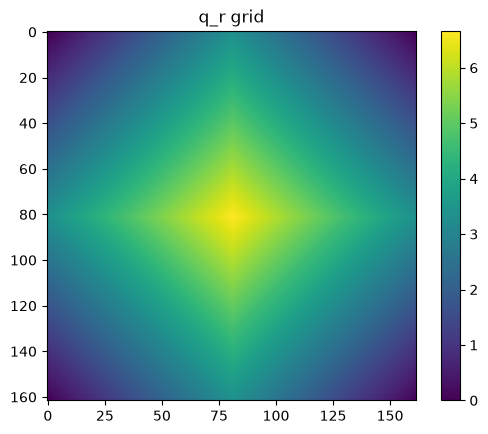

In [134]:
q_x, q_y = ptycho._return_upsampled_qgrid()
# q_x, q_y = np.meshgrid(ft_ax, ft_ax, indexing='ij')
# q_r = np.sqrt(q_x**2 + q_y**2)
q_r = np.abs(q_x) + np.abs(q_y)
# q_r = q_x + q_y

scan_spectra_base = np.abs(ptycho._vbf_fourier).sum(axis=0)
scan_spectra_merged = np.abs(ptycho_merged._vbf_fourier).sum(axis=0)

plt.imshow(q_r), plt.colorbar(), plt.title('q_r grid')

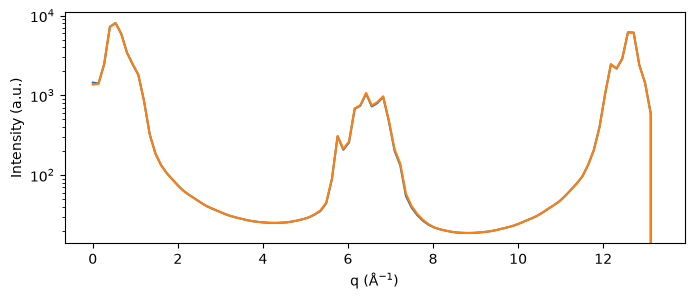

In [133]:
q_r_collapsed = np.linspace(q_r.min(), q_r.max(), 100)
scan_spectra_base_1d = np.zeros_like(q_r_collapsed)
scan_spectra_merged_1d = np.zeros_like(q_r_collapsed)
for i, q in enumerate(q_r_collapsed[:-1]):
    next_q = q_r_collapsed[i + 1]
    mask = (q_r >= q) & (q_r < next_q)
    # mask_size = 1
    # mask_size = mask.sum()
    # if mask_size > 0:
    scan_spectra_base_1d[i] = scan_spectra_base[mask].mean()
    scan_spectra_merged_1d[i] = scan_spectra_merged[mask].mean()


plt.figure(figsize=(8, 3))
plt.plot(q_r_collapsed, (scan_spectra_base_1d), label='Base') 
plt.plot(q_r_collapsed, (scan_spectra_merged_1d), label='Merged')
# plt.plot(q_r_collapsed, (scan_spectra_merged_1d-scan_spectra_base_1d), label='Merged')
plt.xlabel('q (Å$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.yscale('log')

/tmp/ipykernel_839602/2873200102.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  q = np.mod(q_x + q_y, 2 * q_s)
/tmp/ipykernel_839602/2873200102.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mask = np.abs(q_x - q_y) / np.sqrt(2) <= strip_size * dq
/tmp/ipykernel_839602/2873200102.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  spectra = [np.abs(x._vbf_fourier).sum(0)[mask] for x in (ptycho, ptycho_merged)]


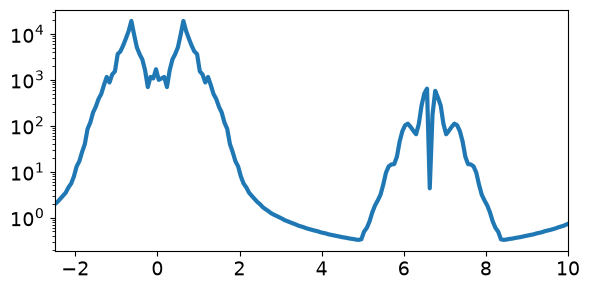

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic

strip_size = 3
q_x, q_y = ptycho._return_upsampled_qgrid()
dq = np.median(np.diff(np.unique(q_x)))
q_s = dq * len(np.unique(q_x))
q = np.mod(q_x + q_y, 2 * q_s)
mask = np.abs(q_x - q_y) / np.sqrt(2) <= strip_size * dq
q = np.concatenate((q[mask] - 2*q_s, q[mask]))
edges = np.linspace(-q_s, 2*q_s, 301)
spectra = [np.abs(x._vbf_fourier).sum(0)[mask] for x in (ptycho, ptycho_merged)]
collapsed = [binned_statistic(q, np.tile(s, 2), bins=edges).statistic for s in spectra]
q_plot = (edges[:-1] + edges[1:]) / 2

plt.figure(figsize=(6, 3))
# plt.plot(q_plot, collapsed[0], label="Base", linewidth=3)
plt.plot(q_plot, collapsed[1], label="Merged", linewidth=3)
# plt.axvline(-q_s, color="0.5", ls="--")
# plt.axvline(q_s, color="0.5", ls="--", label="Nyquist")
# plt.xlabel(r"Diagonal modulation frequency ($\mathrm{\AA}^{-1}$)", fontsize=16)
# plt.ylabel("Mean amplitude (a.u.)", fontsize=16)
plt.yscale("log")
# plt.legend()
plt.xlim(-2.5, 10)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
# plt.legend(fontsize=14)

plt.tight_layout()

In [ ]:
scan_spectra_base[mask]

/tmp/ipykernel_839602/1939196288.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.abs(ptycho._vbf_fourier).sum(axis=0), cmap='hot', vmax=5000)


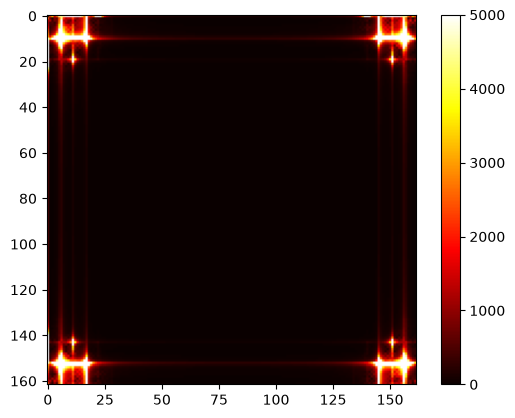

In [24]:
from scipy.ndimage import gaussian_filter
plt.imshow(np.abs(ptycho._vbf_fourier).sum(axis=0), cmap='hot', vmax=5000)
plt.colorbar()

  0%|          | 0/673 [00:00<?, ?it/s]

  0%|          | 0/673 [00:00<?, ?it/s]

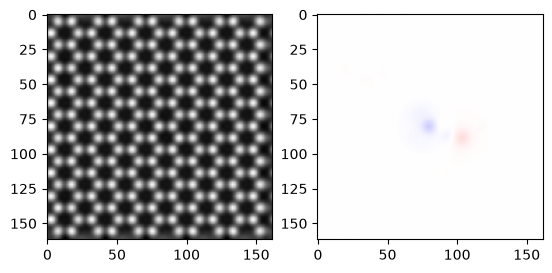

In [25]:
# init dummy
dataset_merged = Dataset4d.from_array(
    merged_scan,
    sampling=(scan_step_size, scan_step_size, 0.04150066401062413, 0.04150066401062413),
    units=("A", "A", "A^-1", "A^-1"),  # or "mrad" for the last two
)

ptycho_merged = DirectPtychography.from_dataset4d(
    dataset_merged,
    energy=60e3,                      # eV
    semiangle_cutoff=30,   # mrad
    aberration_coefs={"defocus": 0},  # Å
).reconstruct(deconvolution_kernel="ssb")
obj_mean = ptycho_merged.obj
plt.figure()
plt.subplot(1,2,1)
plt.imshow(obj_mean, cmap='gray')

# filter_center = ptycho_merged._vbf_fourier.shape[-2] // 2, ptycho_merged._vbf_fourier.shape[-1] // 2
# filter_radius = 5
# qs_filter = np.zeros(ptycho_merged._vbf_fourier.shape[-2:], dtype=np.float32)
# q_ax = np.arange(ptycho_merged._vbf_fourier.shape[-2])
# qs_filter = (
#     (q_ax[np.newaxis, :] - filter_center[0])**2 + (q_ax[:, np.newaxis] - filter_center[1])**2
#     < filter_radius**2
# )
# ptycho_merged._vbf_fourier = ptycho_merged._vbf_fourier * qs_filter[np.newaxis, :, :]

# demodulated the excitation
ptycho_merged._vbf_fourier = torch.fft.fftshift(ptycho_merged._vbf_fourier, dim=(-1, -2))


# reconstruct
ptycho_merged.reconstruct(deconvolution_kernel="ssb")
obj_merged = ptycho_merged.obj  # reconstructed phase, numpy array
plt.subplot(1,2,2)
plt.imshow(obj_merged, cmap='bwr', vmin=-0.02, vmax=0.02)
# plt.imshow(gaussian_filter(obj_merged, sigma=1), cmap='bwr')

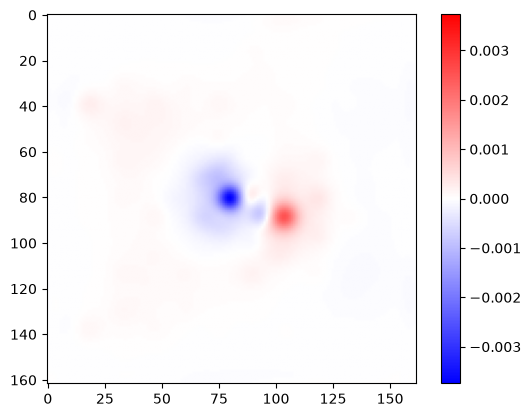

In [26]:
color_extent = np.abs(obj_merged).max()
plt.imshow(obj_merged, cmap='bwr', vmin=-color_extent, vmax=color_extent)
plt.colorbar()

  0%|          | 0/673 [00:00<?, ?it/s]

/tmp/ipykernel_2104453/2808878003.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  filtered_vbf_fourier = ptycho_merged_q_filter._vbf_fourier * qs_filter[np.newaxis, :, :]


  0%|          | 0/673 [00:00<?, ?it/s]

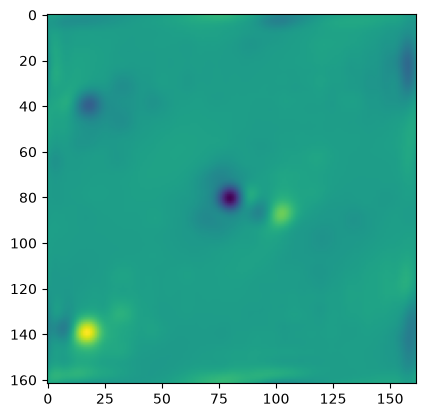

In [45]:
ptycho_merged_q_filter = DirectPtychography.from_dataset4d(
    dataset_merged,
    energy=60e3,                      # eV
    semiangle_cutoff=30,   # mrad
    aberration_coefs={"defocus": 0},  # Å
).reconstruct(deconvolution_kernel="ssb")

ptycho_merged_q_filter._preprocess()

filter_center = ptycho_merged_q_filter._vbf_fourier.shape[-2] // 2, ptycho_merged_q_filter._vbf_fourier.shape[-1] // 2
filter_radius = 20
qs_filter = np.zeros(ptycho_merged_q_filter._vbf_fourier.shape[-2:], dtype=np.float32)
q_ax = np.arange(ptycho_merged_q_filter._vbf_fourier.shape[-2])
qs_filter = (
    (q_ax[np.newaxis, :] - filter_center[0])**2 + (q_ax[:, np.newaxis] - filter_center[1])**2
    < filter_radius**2
)
filtered_vbf_fourier = ptycho_merged_q_filter._vbf_fourier * qs_filter[np.newaxis, :, :]

filtered_vbf_fourier = torch.roll(filtered_vbf_fourier, dims=(-1, -2))
ptycho_merged_q_filter._vbf_fourier = torch.fft.fftshift(filtered_vbf_fourier, dim=(-1, -2))
ptycho_merged_q_filter.reconstruct(deconvolution_kernel="ssb")
obj_merged_q_filtered = ptycho_merged_q_filter.obj  # reconstructed phase, numpy array
plt.imshow(obj_merged_q_filtered)

In [ ]:
ptycho_merged_q_filter

In [25]:
ptycho._vbf_fourier.shape

torch.Size([673, 162, 162])

# SSB-ish for base and excited state

In [ ]:
merged_partial_ft = np.fft.fftn(merged_scan, axes=(0, 1))
base_partial_ft = np.fft.fftn(base_meas.array, axes=(0, 1))
excited_partial_ft = np.fft.fftn(base_meas.array, axes=(0, 1))

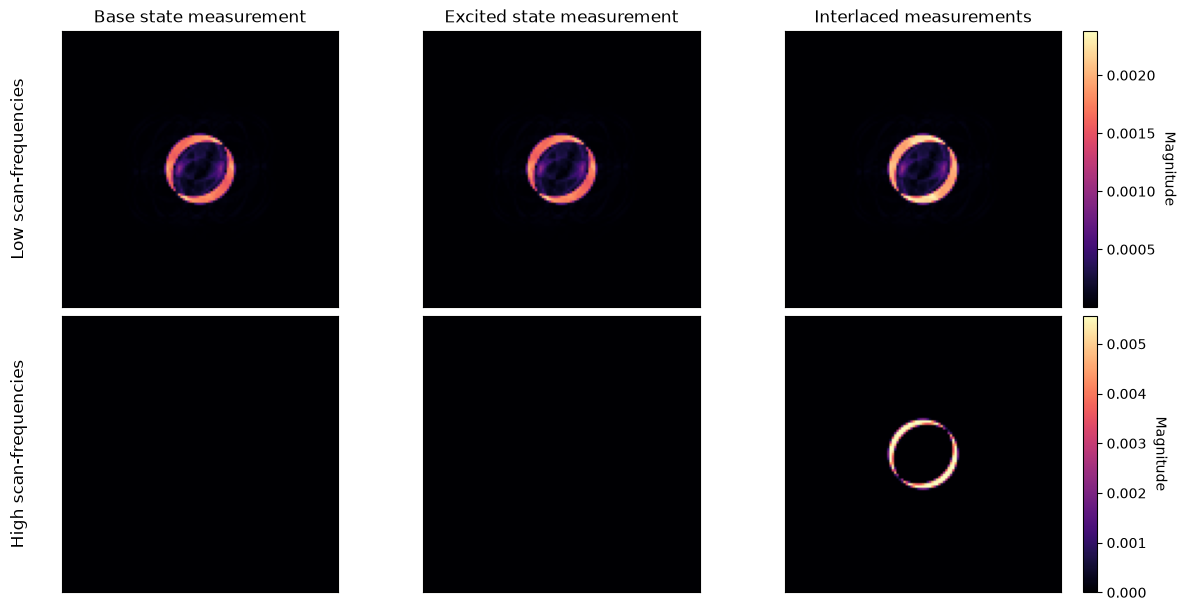

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

loc_low_f = (3, 3)
loc_high_f = (83, 83)

low_imgs = [
    np.abs(base_partial_ft[*loc_low_f, ...]),
    np.abs(excited_partial_ft[*loc_low_f, ...]),
    np.abs(merged_partial_ft[*loc_low_f, ...]),
]

high_imgs = [
    np.abs(base_partial_ft[*loc_high_f, ...]),
    np.abs(excited_partial_ft[*loc_high_f, ...]),
    np.abs(merged_partial_ft[*loc_high_f, ...]),
]

imgs = [low_imgs, high_imgs]

col_titles = [
    "Base state measurement",
    "Excited state measurement",
    "Interlaced measurements",
]

row_titles = [
    "Low scan-frequencies",
    "High scan-frequencies",
]

fig, axs = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)

for row in range(2):
    row_vmin = min(im.min() for im in imgs[row])
    row_vmax = max(im.max() for im in imgs[row])

    ims = []
    for col in range(3):
        im = axs[row, col].imshow(
            imgs[row][col],
            cmap="magma",
            vmin=row_vmin,
            vmax=row_vmax,
        )
        ims.append(im)

        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])

        if row == 0:
            axs[row, col].set_title(col_titles[col], fontsize=12)

    axs[row, 0].set_ylabel(row_titles[row], fontsize=12, labelpad=25)

    cbar = fig.colorbar(
        ims[-1],
        ax=axs[row, :],
        location="right",
        fraction=0.025,
        pad=0.02,
    )
    cbar.set_label("Magnitude", rotation=270, labelpad=15)

plt.show()

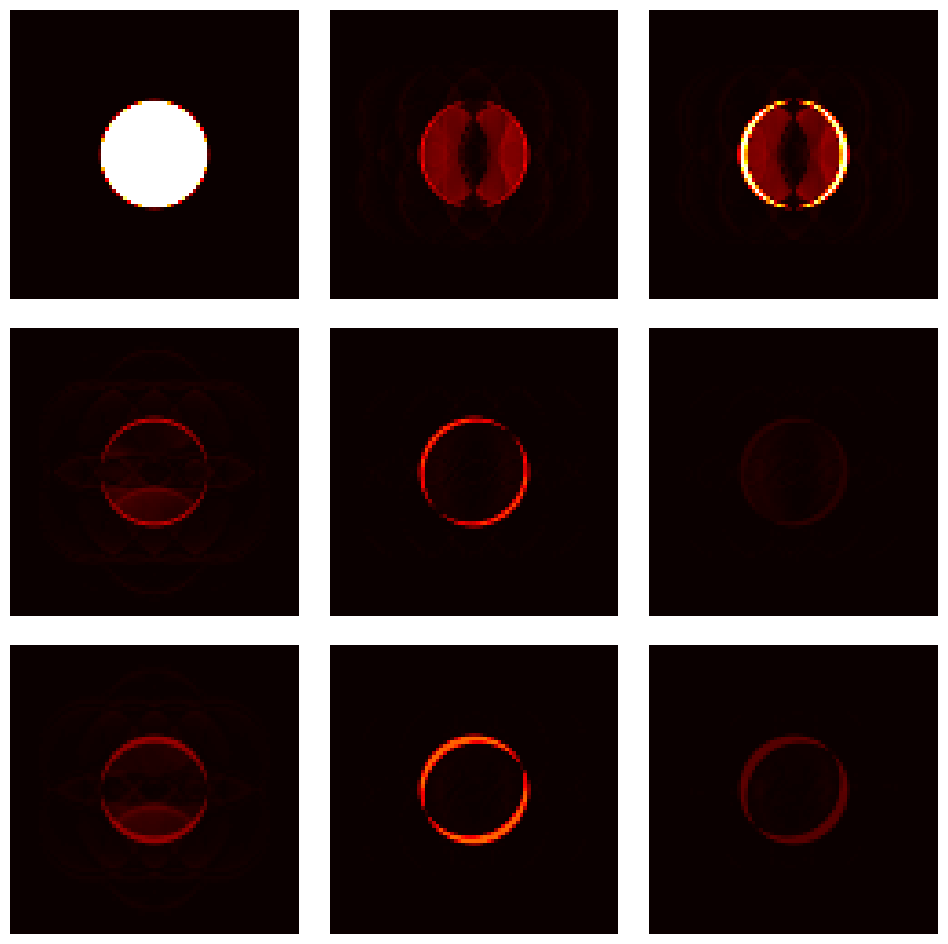

In [111]:
plt.figure(figsize=(12,12))
n = 3
color_extent = np.abs(base_partial_ft[:n, :n, ...])# .max()
color_extent[0,0,...] = 0
color_extent = color_extent.max()
for i in range(0, n):
    for j in range(0, n):
        plt.subplot(n, n, j * n + i + 1)
        if i == j == 0:
            plt.imshow(
                np.abs(base_partial_ft[j, i, 20:-20,20:-20]), 
                cmap='hot'
                )   
        else:
            plt.imshow(
                np.abs(base_partial_ft[j, i, 20:-20,20:-20]), 
                vmin=0, 
                vmax=color_extent,
                cmap='hot'
                )
        plt.axis('off')

plt.subplots_adjust(
    wspace=0.1,   # horizontal gap
    hspace=0.1    # vertical gap
)

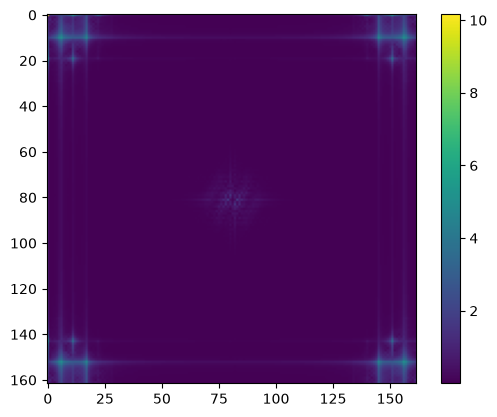

In [33]:
plt.imshow(np.log1p(np.abs(merged_partial_ft).sum(axis=(-1, -2))))
plt.colorbar()

# Crap

In [11]:
base_ssb = np.fft.fftn(base_meas, axes=(0, 1))
excited_ssb = np.fft.fftn(excited_meas, axes=(0, 1))

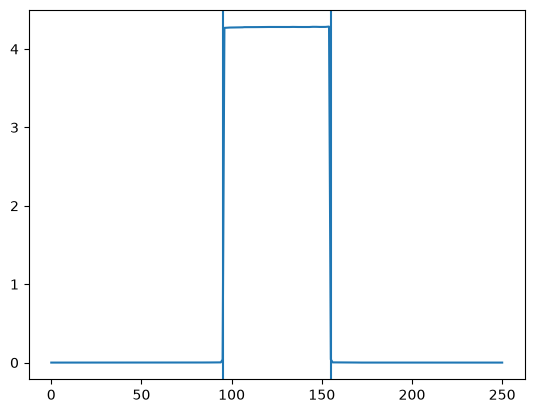

In [46]:
np.abs(base_ssb[0,0])
plt.plot(amp[125,:])
s = 95
e = 155
plt.axvline(s)
plt.axvline(e)
diam = e - s
radius_pix = diam / 2

In [115]:
30 / 1000 / energy2wavelength(200e3)

1.196203712713752

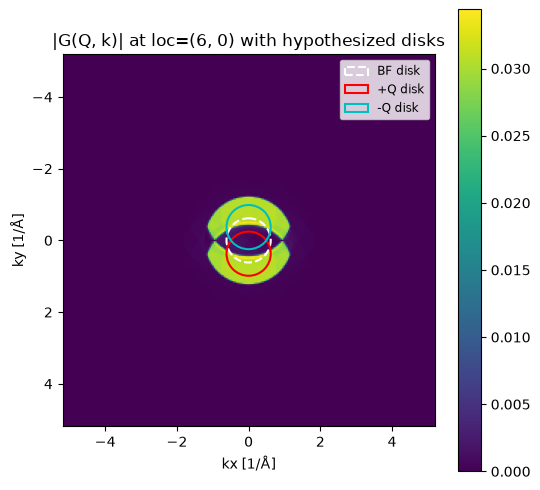

In [105]:
plot_ssb_sidelobes(base_ssb, (6, 0),  x, y, scan_sampling, 1.18)

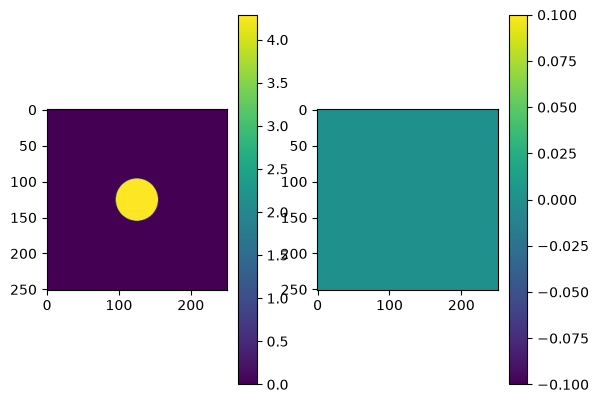

In [39]:
loc = 0, 0
amp = np.abs(base_ssb[*loc])
phase = np.angle(base_ssb[*loc])
amp_mask = amp > 1e-3
masked_phase = phase * amp_mask 

plt.subplot(1, 2, 1)
plt.imshow(amp)
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(masked_phase)
plt.colorbar()

In [ ]:
scan_mask = np.zeros(excited_meas.shape[:2], dtype=np.uint8)
x_i = np.arange(scan_mask.shape[0])
y_i = np.arange(scan_mask.shape[1])
for i in x_i:
    for j in y_i:
        if (i + j) % 2 == 0:
            scan_mask[i, j] = 3
plt.imshow(scan_mask)
plt.colorbar()

In [11]:
import numpy as np
dcube_partial_ft = np.fft.fftn(merged_scan, axes=(0,1))

In [54]:
merged_scan.shape

(56, 56, 128, 128)

In [65]:
pix_ax = np.arange(-64, 64)


(128,)

radius: 7.0 [pixels]


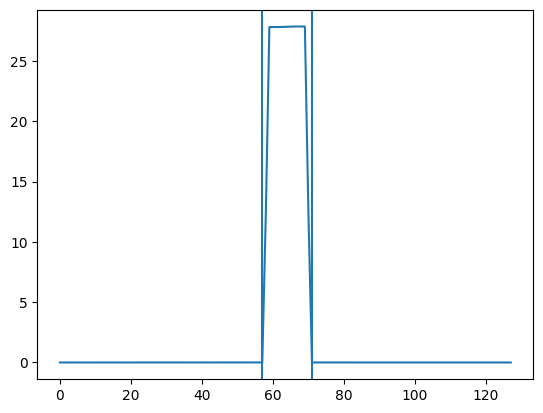

In [73]:
plt.plot(np.abs(dcube_partial_ft[0,0,64,:]))
start = 57
end = 71
plt.axvline(start)
plt.axvline(end)
diam = end - start
radius = diam / 2
print(f'radius: {radius} [pixels]')

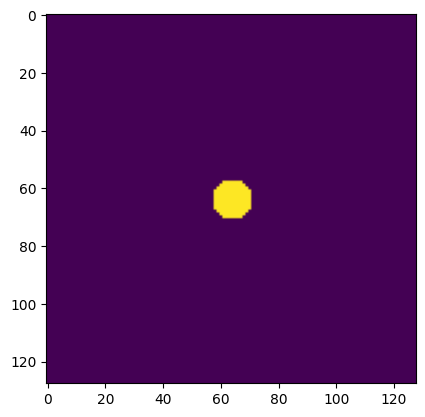

In [77]:
mask = pix_ax[:, None]**2 + pix_ax[None, :]**2 < radius**2
plt.imshow(mask)

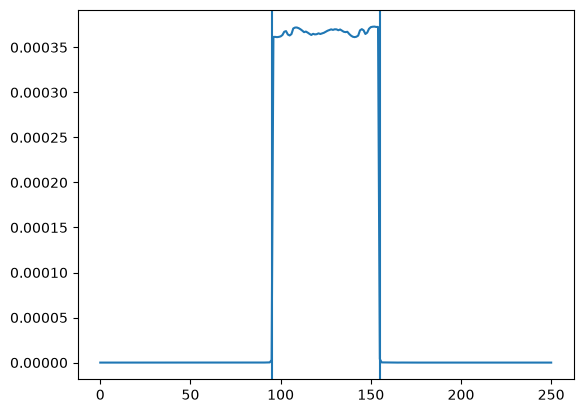

In [136]:
plt.plot(base_meas[0,0,125,:])
plt.axvline(155)
plt.axvline(95)

In [137]:
155 - 95

60

In [123]:
dx = x[1] - x[0]

In [146]:
base_meas.shape[0] * scan_sampling

20.25

In [18]:
base_meas.sampling

(0.04150066401062413, 0.04150066401062413)

In [129]:
obj

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(108, 108), dtype=float32)

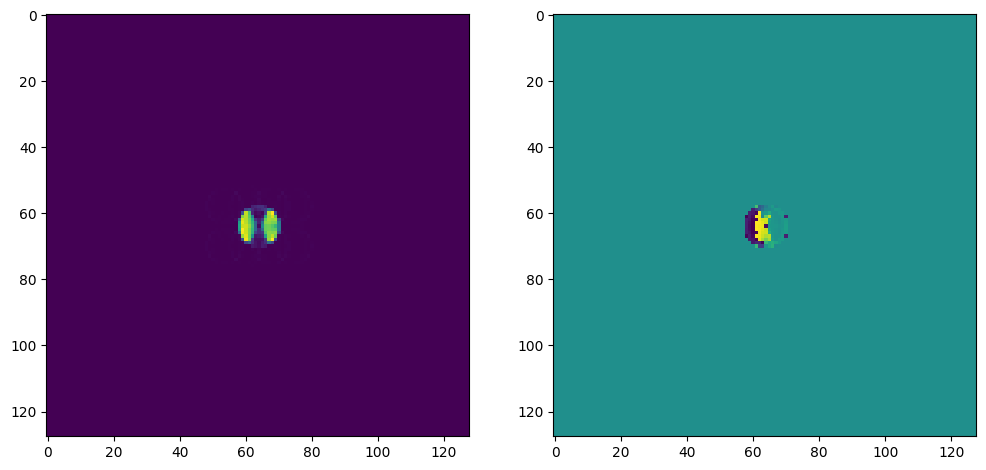

In [79]:
loc = 0,1
amp = np.abs(dcube_partial_ft[*loc])
masked_phase = np.angle(dcube_partial_ft[*loc]) * mask
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(amp)
plt.subplot(1,2,2)
plt.imshow(masked_phase)
# plt.colorbar()

In [ ]:
import numpy as np

def get_phase_q_comp(dcube, q_x_idx, q_y_idx, aperture_radius_px):
    """
    Single-sideband phase of one object Fourier component, assuming an
    aberration-free, hard-edged circular probe aperture.

    dcube: (num_bf, ny, nx) real-valued virtual-BF image stack, one image
        per bright-field detector pixel, flattened in row-major order
        over the same aperture mask used to build `bf_mask` below.
    q_x_idx, q_y_idx: pixel indices of the desired object frequency on
        the same (ny, nx) FFT grid as dcube.
    aperture_radius_px: BF disk radius in pixels, on that same grid.
    """
    ny, nx = dcube.shape[-2:]

    # FFT over scan position -> G(Q, k) for every detector pixel k
    g_q = np.fft.fft2(dcube, axes=(-2, -1))[:, q_y_idx, q_x_idx]  # (num_bf,)

    # k-space grid, in pixel units
    ky = np.fft.fftfreq(ny) * ny
    kx = np.fft.fftfreq(nx) * nx
    kya, kxa = np.meshgrid(ky, kx, indexing="ij")

    bf_mask = kxa**2 + kya**2 <= aperture_radius_px**2
    qx, qy = kx[q_x_idx], ky[q_y_idx]

    kx_bf, ky_bf = kxa[bf_mask], kya[bf_mask]  # order matches dcube's num_bf axis

    a_minus = (kx_bf - qx) ** 2 + (ky_bf - qy) ** 2 <= aperture_radius_px**2
    a_plus = (kx_bf + qx) ** 2 + (ky_bf + qy) ** 2 <= aperture_radius_px**2

    sideband = a_minus ^ a_plus                # exactly one shifted disk overlaps k
    sign = np.where(a_minus, 1.0, -1.0)         # +1 in the "minus" lobe, -1 in the "plus" lobe

    obj_q = np.sum(-1j * g_q[sideband] * sign[sideband])
    return np.angle(obj_q)


In [116]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle


def _as_pair(x, name):
    if np.isscalar(x):
        return float(x), float(x)
    if len(x) != 2:
        raise ValueError(f"{name} must be a scalar or a length-2 tuple/list.")
    return float(x[0]), float(x[1])


def _estimate_disk(mean_dp, det_kx, det_ky, threshold_rel):
    """
    Rough bright-field disk center/radius estimate from the mean diffraction pattern.
    For serious quantitative work, pass disk_center and disk_radius explicitly.
    """
    mean_dp = np.asarray(mean_dp, dtype=float)
    det_kx = np.asarray(det_kx, dtype=float)
    det_ky = np.asarray(det_ky, dtype=float)

    lo = np.nanpercentile(mean_dp, 5)
    hi = np.nanmax(mean_dp)

    threshold = lo + threshold_rel * (hi - lo)
    mask = np.isfinite(mean_dp) & (mean_dp > threshold)

    if mask.sum() < 5:
        threshold = np.nanpercentile(mean_dp, 99)
        mask = np.isfinite(mean_dp) & (mean_dp > threshold)

    xgrid, ygrid = np.meshgrid(det_kx, det_ky, indexing="ij")

    weights = np.where(mask, np.clip(mean_dp - lo, 0, None), 0.0)
    if weights.sum() <= 0:
        weights = mask.astype(float)

    cx = float((xgrid * weights).sum() / weights.sum())
    cy = float((ygrid * weights).sum() / weights.sum())

    dkx = float(abs(np.median(np.diff(det_kx)))) if det_kx.size > 1 else 1.0
    dky = float(abs(np.median(np.diff(det_ky)))) if det_ky.size > 1 else 1.0

    area = float(mask.sum() * dkx * dky)
    radius = float(np.sqrt(area / np.pi))

    return (cx, cy), radius


def _display_complex(z, display):
    display = display.lower()

    if display == "logabs":
        return np.log1p(np.abs(z))
    if display == "abs":
        return np.abs(z)
    if display == "real":
        return np.real(z)
    if display == "imag":
        return np.imag(z)
    if display == "phase":
        return np.angle(z)

    raise ValueError(
        "display must be one of: 'logabs', 'abs', 'real', 'imag', 'phase'."
    )


def plot_ssb_sidebands(
    datacube,
    scan_step,
    q_pixel_offsets=None,
    q_points=None,
    detector_kx=None,
    detector_ky=None,
    detector_pixel_size=None,
    disk_center=None,
    disk_radius=None,
    q_multiplier=1.0,
    q_to_detector_pixels=1.0,
    q_to_detector_matrix=None,
    subtract_scan_mean=False,
    normalize=True,
    display="logabs",
    auto_disk_threshold=0.25,
    cmap="magma",
    show_colorbar=True,
    figsize=None,
):
    """
    Plot SSB / partial-FT detector images and overlay expected BF disk locations.

    Parameters
    ----------
    datacube : ndarray
        Shape [scan_x, scan_y, k_x, k_y].

    scan_step : float or tuple
        Scan step size in real-space units, e.g. Angstrom.
        If your phase-image pixels are dx, dy, use scan_step=(dx, dy).

    q_pixel_offsets : list of tuple[int, int], optional
        Fourier-pixel offsets from q=0 in the shifted scan FFT grid.
        Example: [(4, 0), (8, 0), (8, 8)].

    q_points : list of tuple[float, float], optional
        Desired q values in reciprocal units, e.g. inverse Angstrom.
        The nearest FFT-bin is plotted.

    detector_kx, detector_ky : ndarray, optional
        Detector reciprocal-space axes.
        Must have lengths datacube.shape[2] and datacube.shape[3].
        These should be in the same units as qx, qy unless using q_to_detector_matrix.

    detector_pixel_size : float or tuple, optional
        Alternative to detector_kx/detector_ky.
        Pixel size of detector reciprocal-space grid.

    disk_center : tuple, optional
        BF disk center in detector coordinates.
        If None, estimated from mean diffraction pattern.

    disk_radius : float, optional
        BF disk radius in detector coordinates.
        If None, estimated from mean diffraction pattern.

    q_multiplier : float
        Multiplier applied to q before overlaying shifted disks.
        Use q_multiplier=2*np.pi if your detector coordinates are angular/radian
        wavevectors while scan FFT frequencies are in cycles per length.

    q_to_detector_pixels : float or tuple
        Used only when no detector calibration is supplied.
        Converts scan q units into detector pixel shifts.

    q_to_detector_matrix : ndarray, shape (2, 2), optional
        General mapping from scan q to detector shift:
            [dkx_detector, dky_detector] = M @ [qx_scan, qy_scan]
        Useful for detector/scan rotation, flips, anisotropic scaling, etc.

    subtract_scan_mean : bool
        If True, subtracts the mean diffraction pattern before the partial FT.
        This suppresses the q=0 term but is not required for nonzero q.

    normalize : bool
        If True, divide partial FT by number of scan positions.

    display : str
        One of 'logabs', 'abs', 'real', 'imag', 'phase'.

    Returns
    -------
    fig, axes, info
        info contains the partial FT, q axes, selected q values, and disk parameters.

    Notes
    -----
    For a selected object frequency q, the expected SSB overlap comes from the
    central BF disk and the disks shifted by +q and -q.

    This function computes the full scan-direction partial FT, so the returned
    complex array has the same size as the original datacube.
    """

    cube = np.asarray(datacube)

    if cube.ndim != 4:
        raise ValueError("datacube must have shape [scan_x, scan_y, k_x, k_y].")

    n_scan_x, n_scan_y, n_kx, n_ky = cube.shape
    step_x, step_y = _as_pair(scan_step, "scan_step")

    # Scan reciprocal-space axes: qx, qy.
    # Units are cycles / real-space-unit because np.fft.fftfreq uses exp(-2πi...).
    qx = np.fft.fftshift(np.fft.fftfreq(n_scan_x, d=step_x))
    qy = np.fft.fftshift(np.fft.fftfreq(n_scan_y, d=step_y))

    q0_ix = int(np.argmin(np.abs(qx)))
    q0_iy = int(np.argmin(np.abs(qy)))

    # Detector coordinate handling.
    detector_mode = "reciprocal"

    if detector_kx is None and detector_ky is None:
        if detector_pixel_size is None:
            # Fallback: detector pixel coordinates centered at zero.
            # Overlay is only diagnostic unless q_to_detector_pixels is calibrated.
            detector_mode = "pixels"
            detector_kx = np.arange(n_kx, dtype=float) - (n_kx - 1) / 2
            detector_ky = np.arange(n_ky, dtype=float) - (n_ky - 1) / 2
        else:
            dkx, dky = _as_pair(detector_pixel_size, "detector_pixel_size")
            detector_kx = (np.arange(n_kx, dtype=float) - (n_kx - 1) / 2) * dkx
            detector_ky = (np.arange(n_ky, dtype=float) - (n_ky - 1) / 2) * dky

    elif detector_kx is None or detector_ky is None:
        raise ValueError("Provide both detector_kx and detector_ky, or neither.")

    else:
        detector_kx = np.asarray(detector_kx, dtype=float)
        detector_ky = np.asarray(detector_ky, dtype=float)

    if detector_kx.size != n_kx or detector_ky.size != n_ky:
        raise ValueError(
            "detector_kx and detector_ky must match the detector dimensions of datacube."
        )

    # Estimate BF disk if not provided.
    mean_dp = cube.mean(axis=(0, 1))

    if disk_center is None or disk_radius is None:
        est_center, est_radius = _estimate_disk(
            mean_dp,
            detector_kx,
            detector_ky,
            auto_disk_threshold,
        )

        if disk_center is None:
            disk_center = est_center
        if disk_radius is None:
            disk_radius = est_radius

    disk_center = (float(disk_center[0]), float(disk_center[1]))
    disk_radius = float(disk_radius)

    # Choose q points to plot.
    selected = []

    if q_points is not None:
        for qx_target, qy_target in q_points:
            ix = int(np.argmin(np.abs(qx - qx_target)))
            iy = int(np.argmin(np.abs(qy - qy_target)))
            selected.append((ix, iy))

    if q_pixel_offsets is not None:
        for ox, oy in q_pixel_offsets:
            ix = q0_ix + int(ox)
            iy = q0_iy + int(oy)

            if 0 <= ix < n_scan_x and 0 <= iy < n_scan_y:
                selected.append((ix, iy))
            else:
                raise ValueError(
                    f"q_pixel_offset {(ox, oy)} is outside the shifted FFT grid."
                )

    if len(selected) == 0:
        ox = max(1, n_scan_x // 8)
        oy = max(1, n_scan_y // 8)

        defaults = [
            (ox, 0),
            (0, oy),
            (ox, oy),
            (-ox, oy),
        ]

        for ox, oy in defaults:
            ix = q0_ix + ox
            iy = q0_iy + oy

            if 0 <= ix < n_scan_x and 0 <= iy < n_scan_y:
                selected.append((ix, iy))

    # Remove duplicates while keeping order.
    seen = set()
    selected = [
        (ix, iy)
        for ix, iy in selected
        if not ((ix, iy) in seen or seen.add((ix, iy)))
    ]

    # Partial FT over scan dimensions only.
    if subtract_scan_mean:
        work = cube - cube.mean(axis=(0, 1), keepdims=True)
    else:
        work = cube

    G = np.fft.fftshift(np.fft.fft2(work, axes=(0, 1)), axes=(0, 1))

    if normalize:
        G = G / (n_scan_x * n_scan_y)

    # Mapping from scan q to detector shift.
    if q_to_detector_matrix is not None:
        q_to_detector_matrix = np.asarray(q_to_detector_matrix, dtype=float)
        if q_to_detector_matrix.shape != (2, 2):
            raise ValueError("q_to_detector_matrix must be a 2x2 matrix.")
    else:
        if detector_mode == "pixels":
            px_per_qx, px_per_qy = _as_pair(
                q_to_detector_pixels,
                "q_to_detector_pixels",
            )
            q_to_detector_matrix = q_multiplier * np.array(
                [
                    [px_per_qx, 0.0],
                    [0.0, px_per_qy],
                ]
            )
        else:
            q_to_detector_matrix = q_multiplier * np.eye(2)

    # Plotting.
    n_panels = len(selected)
    n_cols = min(3, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))

    if figsize is None:
        figsize = (5.2 * n_cols, 4.6 * n_rows)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    axes_flat = axes.ravel()

    extent = [
        detector_kx.min(),
        detector_kx.max(),
        detector_ky.min(),
        detector_ky.max(),
    ]

    cx, cy = disk_center
    selected_info = []

    for ax, (ix, iy) in zip(axes_flat, selected):
        q_vec = np.array([qx[ix], qy[iy]], dtype=float)
        dkx_shift, dky_shift = q_to_detector_matrix @ q_vec

        image = _display_complex(G[ix, iy], display)

        # image is [kx, ky], but imshow expects [y, x], so transpose.
        im = ax.imshow(
            image.T,
            origin="lower",
            extent=extent,
            aspect="equal",
            cmap=cmap,
        )

        # Central BF disk.
        ax.add_patch(
            Circle(
                (cx, cy),
                disk_radius,
                fill=False,
                edgecolor="white",
                linewidth=1.6,
                label="central disk",
            )
        )

        # Shifted disks: central disk shifted by +q and -q.
        ax.add_patch(
            Circle(
                (cx + dkx_shift, cy + dky_shift),
                disk_radius,
                fill=False,
                edgecolor="cyan",
                linestyle="--",
                linewidth=1.4,
                label="+q shifted disk",
            )
        )

        ax.add_patch(
            Circle(
                (cx - dkx_shift, cy - dky_shift),
                disk_radius,
                fill=False,
                edgecolor="yellow",
                linestyle=":",
                linewidth=1.6,
                label="-q shifted disk",
            )
        )

        ax.set_title(
            f"q index offset = ({ix - q0_ix:+d}, {iy - q0_iy:+d})\n"
            f"q = ({qx[ix]:.4g}, {qy[iy]:.4g})"
        )

        unit_label = "pixel" if detector_mode == "pixels" else "k"
        ax.set_xlabel(f"detector kx [{unit_label} units]")
        ax.set_ylabel(f"detector ky [{unit_label} units]")

        if show_colorbar:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        selected_info.append(
            {
                "q_index": (ix, iy),
                "q_index_offset_from_zero": (ix - q0_ix, iy - q0_iy),
                "q": (float(qx[ix]), float(qy[iy])),
                "detector_shift": (float(dkx_shift), float(dky_shift)),
            }
        )

    for ax in axes_flat[n_panels:]:
        ax.axis("off")

    if n_panels > 0:
        axes_flat[0].legend(loc="upper right", fontsize=8)

    fig.tight_layout()

    info = {
        "partial_ft": G,
        "qx": qx,
        "qy": qy,
        "selected": selected_info,
        "disk_center": disk_center,
        "disk_radius": disk_radius,
        "detector_mode": detector_mode,
    }

    return fig, axes_flat[:n_panels], info

(<Figure size 1560x920 with 10 Axes>,
 array([<Axes: title={'center': 'q index offset = (+13, +0)\nq = (0.8025, 0)'}, xlabel='detector kx [pixel units]', ylabel='detector ky [pixel units]'>,
        <Axes: title={'center': 'q index offset = (+0, +13)\nq = (0, 0.8025)'}, xlabel='detector kx [pixel units]', ylabel='detector ky [pixel units]'>,
        <Axes: title={'center': 'q index offset = (+13, +13)\nq = (0.8025, 0.8025)'}, xlabel='detector kx [pixel units]', ylabel='detector ky [pixel units]'>,
        <Axes: title={'center': 'q index offset = (-13, +13)\nq = (-0.8025, 0.8025)'}, xlabel='detector kx [pixel units]', ylabel='detector ky [pixel units]'>],
       dtype=object),
 {'partial_ft': array([[[[-1.85676440e-21+5.28375841e-37j,
            -5.00422824e-21-2.64187921e-37j,
             4.31391290e-21-2.64187921e-37j, ...,
             1.36818995e-21+0.00000000e+00j,
            -8.14369259e-22-3.96281870e-37j,
            -9.58874794e-21-1.71722154e-36j],
           [ 6.39129905e

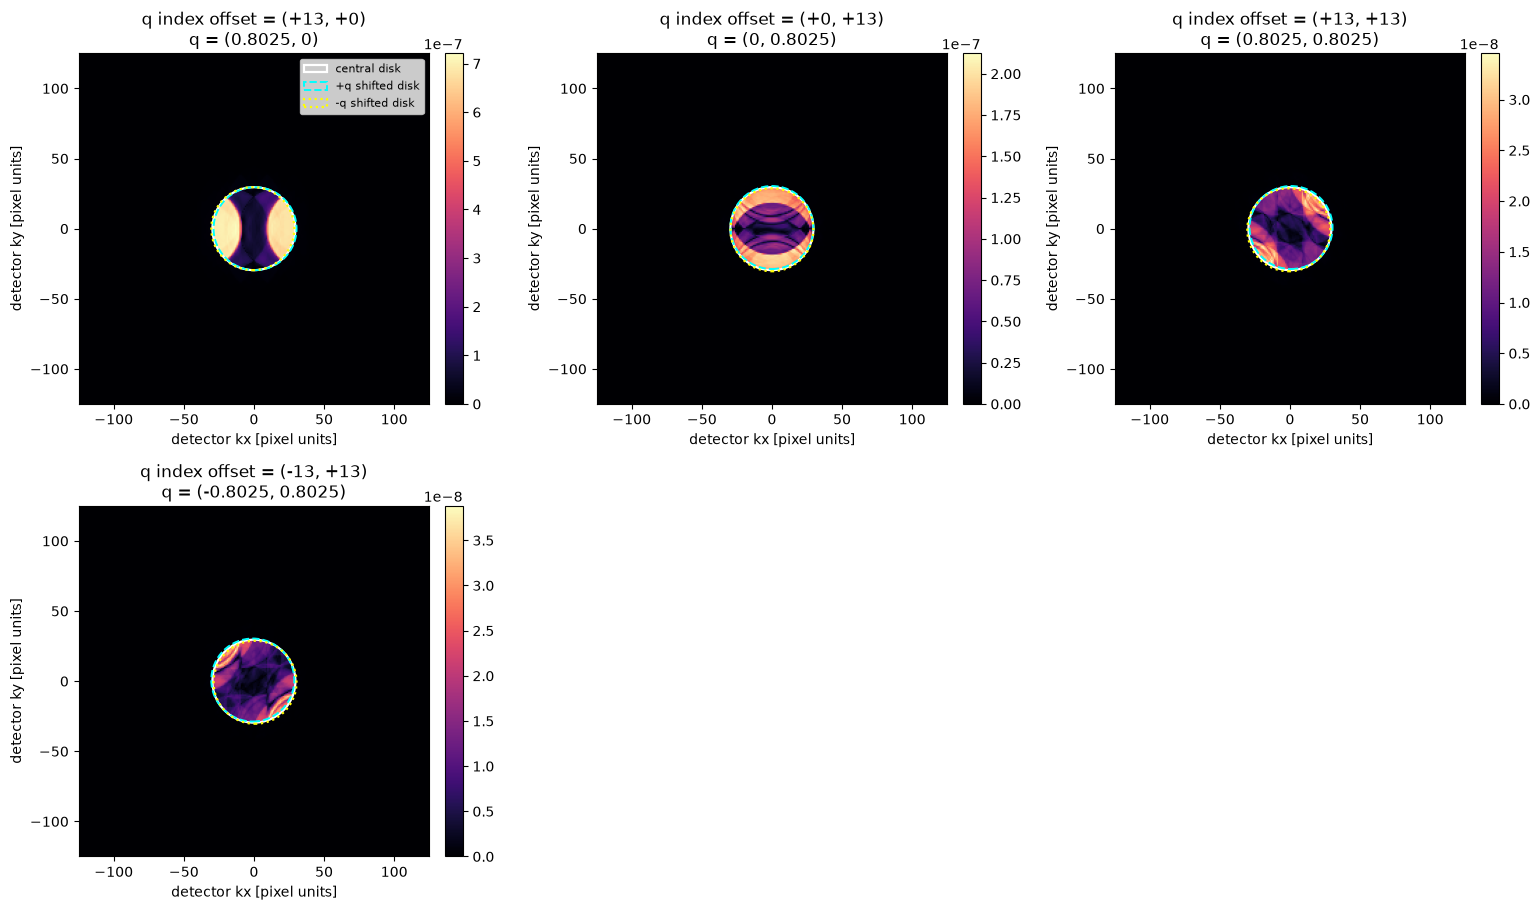

In [119]:
plot_ssb_sidebands(base_meas, 0.15)